# Shape analysis

In [1]:
import requests
import time
import io
import os

import numpy as np
import pandas as pd

import rocks

from figure_mask import compute_mask, print_statistics

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_context("poster")

### Combination DAMIT & SSOFT

In [2]:
# You need SSOFT version 2024.09
# see fink_spins/generate_data.py
data_fink = "../../"
ssoft = pd.read_parquet(os.path.join(data_fink, "data", "ztf", "sso_ZTF.parquet"))

In [3]:
maskFINK_inter = compute_mask(ssoft, thres_spin=1e-3, thres_phase=1e-3, R_min=0.31, model='FINK', kind='inter')
maskFINK_union = compute_mask(ssoft, thres_spin=1e-3, thres_phase=1e-3, R_min=0.31, model='FINK', kind='union')

for model in ['HG', 'HG1G2', 'SHG1G2', 'FINK']:
    print_statistics(ssoft, model)
    print()

mask = maskFINK_union
print(sum(mask))

  All data       : 143703  (100.00%)
  Mask HG (g∩r) : 140827  ( 98.00%)
  Mask HG (gUr) : 140833  ( 98.00%)

  All data       : 143703  (100.00%)
  Mask HG1G2 (g∩r) :  59171  ( 41.18%)
  Mask HG1G2 (gUr) : 103769  ( 72.21%)

  All data       : 143703  (100.00%)
  Mask SHG1G2 (g∩r) :  78492  ( 54.62%)
  Mask SHG1G2 (gUr) : 117136  ( 81.51%)

  All data       : 143703  (100.00%)
  Mask FINK (g∩r) :  53758  ( 37.41%)
  Mask FINK (gUr) :  91600  ( 63.74%)

74621


In [4]:
flavor = "SSHG1G2"

In [5]:
abc = pd.read_csv("../../data/damit_abc.csv")

# Revert b and c if needed 
cond_bc = abc['b'] < abc['c']
print('revert bc', len(abc[cond_bc]))

b = abc.loc[cond_bc,'b']
abc.loc[cond_bc,'b'] = abc.loc[cond_bc,'c']
abc.loc[cond_bc,'c'] = b

# Revert a and b if needed 
cond_ab = abc['a'] < abc['b']
print('revert ab', len(abc[cond_ab]))

a = abc.loc[cond_ab,'a']
abc.loc[cond_ab,'a'] = abc.loc[cond_ab,'b']
abc.loc[cond_ab,'b'] = a


# Revert b and c again if needed 
cond_bc = abc['b'] < abc['c']
print('revert bc', len(abc[cond_bc]))

b = abc.loc[cond_bc,'b']
abc.loc[cond_bc,'b'] = abc.loc[cond_bc,'c']
abc.loc[cond_bc,'c'] = b

# Check
cond_bc = abc['b'] < abc['c']
cond_ab = abc['a'] < abc['b']
print('miss ab, bc', len(abc[cond_ab]), len(abc[cond_bc]))

# abc[cond_bc]
abc

revert bc 0
revert ab 0
revert bc 0
miss ab, bc 0 0


,model_id,asteroid_id,lambda,beta,period,number,name,designation,reference_id,bibcode,a,b,c,R,R2
0,101,101,35.0,-12.0,7.813230,2.0,Pallas,NaN,106,2003icar..164..346t,0.050144,0.047520,0.044016,0.902027,0.902027
1,101,101,35.0,-12.0,7.813230,2.0,Pallas,NaN,139,2011icar..214..652d,0.050144,0.047520,0.044016,0.902027,0.902027
2,106,104,340.0,42.0,7.274471,6.0,Hebe,NaN,106,2003icar..164..346t,0.087539,0.084628,0.074940,0.870793,0.870799
3,106,104,340.0,42.0,7.274471,6.0,Hebe,NaN,139,2011icar..214..652d,0.087539,0.084628,0.074940,0.870793,0.870799
4,110,106,335.0,-5.0,12.866670,8.0,Flora,NaN,106,2003icar..164..346t,0.098508,0.093500,0.086202,0.898516,0.898511
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16312,16275,10853,326.0,-83.0,8.016800,99949.0,Miepgies,NaN,665,2023arxiv230510798d,1.359332,0.883253,0.851780,0.795492,0.795492
16313,16276,10854,34.0,-42.0,143.500000,99973.0,NaN,NaN,665,2023arxiv230510798d,1.510920,0.870606,0.766555,0.693913,0.693914
16314,16277,10854,194.0,-64.0,143.490000,99973.0,NaN,NaN,665,2023arxiv230510798d,1.586496,0.873017,0.728478,0.646806,0.646806
16315,16278,10855,192.0,-52.0,7.071400,99990.0,NaN,NaN,665,2023arxiv230510798d,1.724247,0.872519,0.661044,0.570504,0.570504


## Comparison to literature

In [6]:
data = abc.merge(ssoft[mask], left_on="name", right_on="name", how="left")

# Remove NaN
mask_nan = ~np.isnan(data["SSHG1G2_a_b"])
data = data[mask_nan]

# sort by number of observations
data = data.sort_values("n_obs", ascending=False)
# data = data.sort_values(f'{flavor}_rms', ascending=False)

data["DAMIT_a_b"] = data["a"] / data["b"]
data["DAMIT_a_c"] = data["a"] / data["c"]

col_display = ["name", "DAMIT_a_b", "DAMIT_a_c", "SSHG1G2_a_b", "SSHG1G2_a_c", "n_obs"]

# DAMIT HAS DUPLICATES?
data = data.drop_duplicates("name")

data[col_display].head(50)

,name,DAMIT_a_b,DAMIT_a_c,SSHG1G2_a_b,SSHG1G2_a_c,n_obs
10233,Briggs,1.625192,1.646537,1.628936,1.384183,508.0
8267,Diomedes,1.559108,1.746083,1.666887,2.026654,506.0
7546,Agamemnon,1.287346,1.568217,1.295233,1.742041,501.0
391,Hektor,2.177053,2.407573,2.453351,2.534027,498.0
4419,Brendelia,1.327214,1.345692,1.331946,1.777792,462.0
6453,Ajax,1.196356,1.411893,1.187297,1.286983,454.0
10534,Mariobotta,1.458461,1.550638,1.771698,1.598660,453.0
21808,Palamedes,1.244476,1.732739,1.255201,1.773454,437.0
7506,Kashirina,1.181421,1.498235,1.318993,1.309988,426.0
7652,Achilles,1.423509,1.654868,1.595572,1.791350,425.0


In [7]:
len(data)

2572

In [8]:
# data[data["name"] == "Calpurnia"]

### Distributions

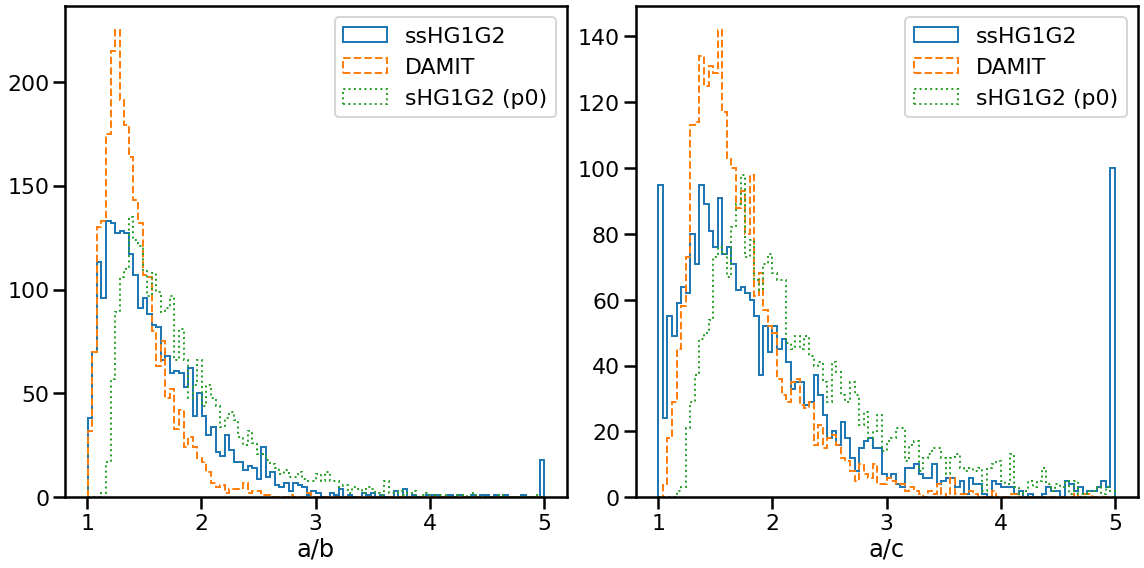

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

r_ab = [1, 3]
r_bc = [1, 3]
r_ac = [1, 3]
b_ab = 50
b_bc = 50
b_ac = 50

fields = ["a_b", "a_c"]
for index in range(2):
    _, bins, _ = axes[index].hist(
        data["SSHG1G2_{}".format(fields[index])], 
        bins=100, label="ssHG1G2",
        histtype="step", lw=2
    )
    axes[index].hist(
        data["DAMIT_{}".format(fields[index])], 
        bins=bins, label="DAMIT",
        histtype="step", ls='--', lw=2
    )
    axes[index].hist(
        data["SHG1G2_{}".format(fields[index])], 
        bins=bins, label="sHG1G2 (p0)",
        histtype="step", ls=":", lw=2
    )
    axes[index].set_xlabel(fields[index].replace("_", "/"))

    axes[index].legend()
plt.tight_layout()

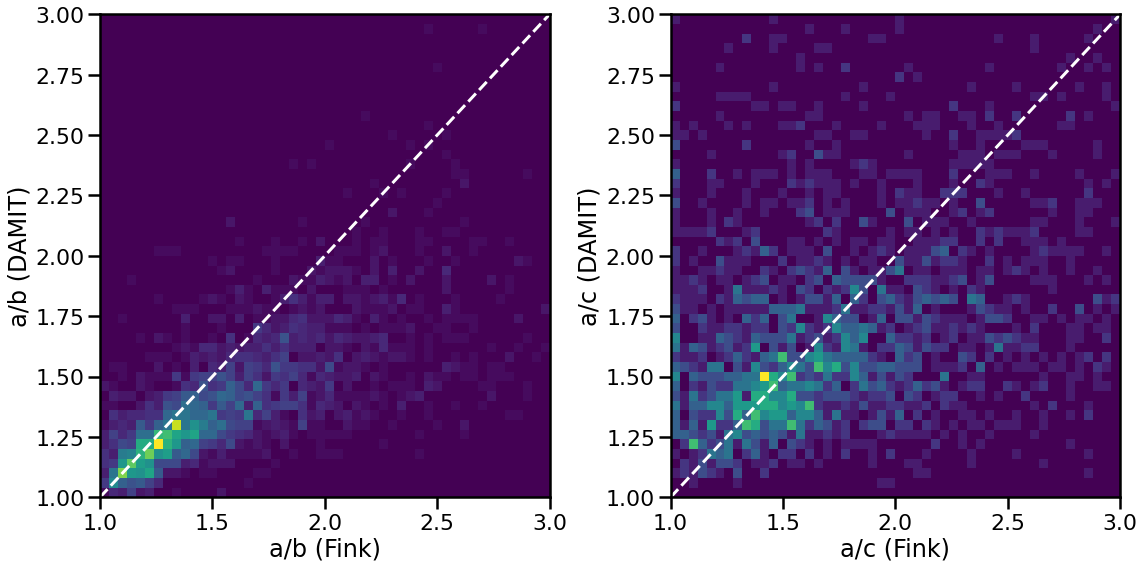

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

r_ab = [1, 3]
r_bc = [1, 3]
r_ac = [1, 3]
b_ab = 50
b_bc = 50
b_ac = 50

fields = ["a_b", "a_c"]
for index in range(2):
    axes[index].hist2d(
        data["SSHG1G2_{}".format(fields[index])], 
        data["DAMIT_{}".format(fields[index])], 
        range=[r_ab, r_bc], 
        bins=[b_ab, b_bc]
    )

    # axes[index].axvline(1.05, color='white', ls=":") # p0 in the fit
    

    axes[index].plot(r_ab, r_bc, color="white", ls='--')
    axes[index].set_xlabel("{} (Fink)".format(fields[index]).replace("_", "/"))
    axes[index].set_ylabel("{} (DAMIT)".format(fields[index]).replace("_", "/"))

# axes[1].legend(prop={'size': 15})
plt.tight_layout()

# Fink - DAMIT period comparison

which is I guess only a subset of what is in the BFT (but no surprise, the pattern is the same)

/tmp/ipykernel_34118/1330305479.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(prop={'size': 15})


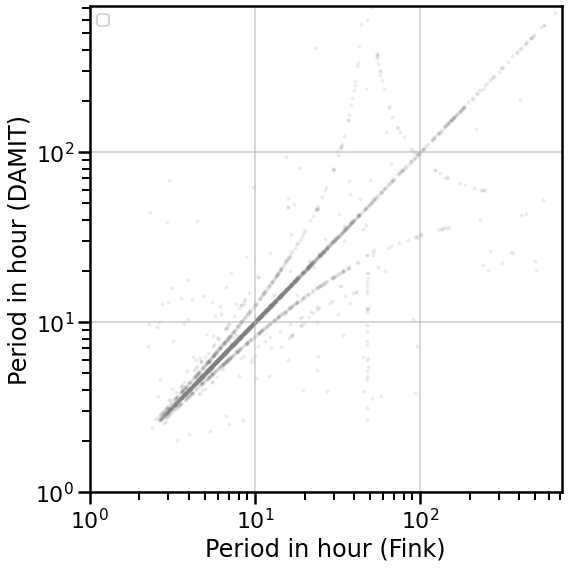

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

maxval = 30*24

ax.scatter(
    data["SSHG1G2_period"],
    data["period"], 
    marker='.', alpha=0.1, s=20, color='grey'
)
# plt.colorbar()
ax.grid(alpha=0.5)
ax.set_xlim(1, maxval)
ax.set_ylim(1, maxval)
ax.set_xlabel("Period in hour (Fink)")
ax.set_ylabel("Period in hour (DAMIT)")
ax.set_xscale("log")
ax.set_yscale("log")

ax.legend(prop={'size': 15})
plt.tight_layout()

## ratio comparison

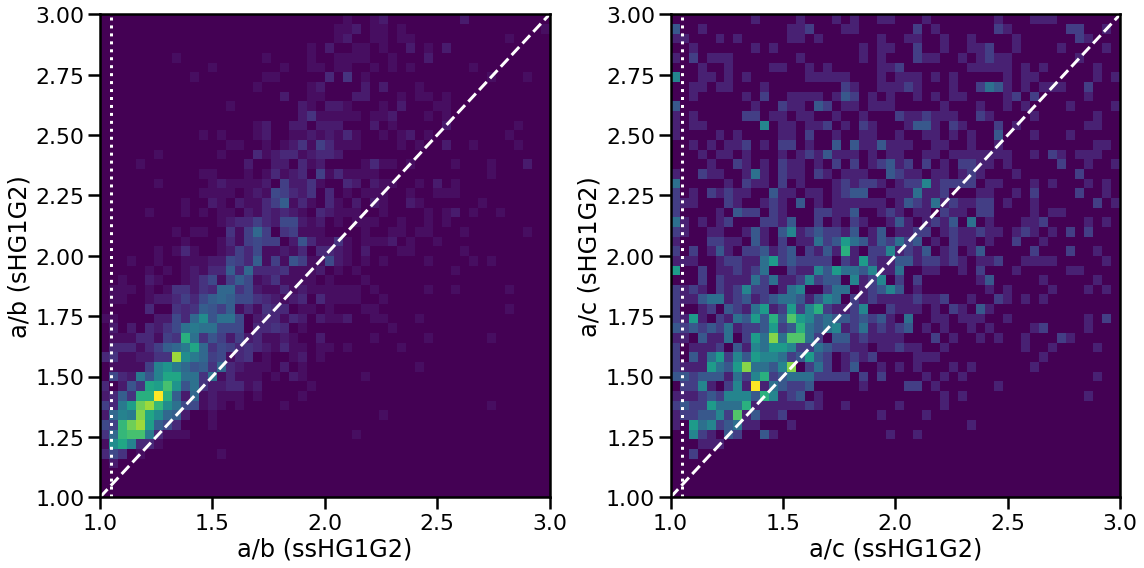

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

r_ab = [1, 3]
r_bc = [1, 3]
r_ac = [1, 3]
b_ab = 50
b_bc = 50
b_ac = 50

fields = ["a_b", "a_c"]
for index in range(2):
    axes[index].hist2d(
        data["SSHG1G2_{}".format(fields[index])], 
        data["SHG1G2_{}".format(fields[index])], 
        range=[r_ab, r_bc], 
        bins=[b_ab, b_bc]
    )

    axes[index].axvline(1.05, color='white', ls=":") # p0 in the fit
    

    axes[index].plot(r_ab, r_bc, color="white", ls='--')
    axes[index].set_xlabel("{} (ssHG1G2)".format(fields[index]).replace("_", "/"))
    axes[index].set_ylabel("{} (sHG1G2)".format(fields[index]).replace("_", "/"))

# axes[1].legend(prop={'size': 15})
plt.tight_layout()

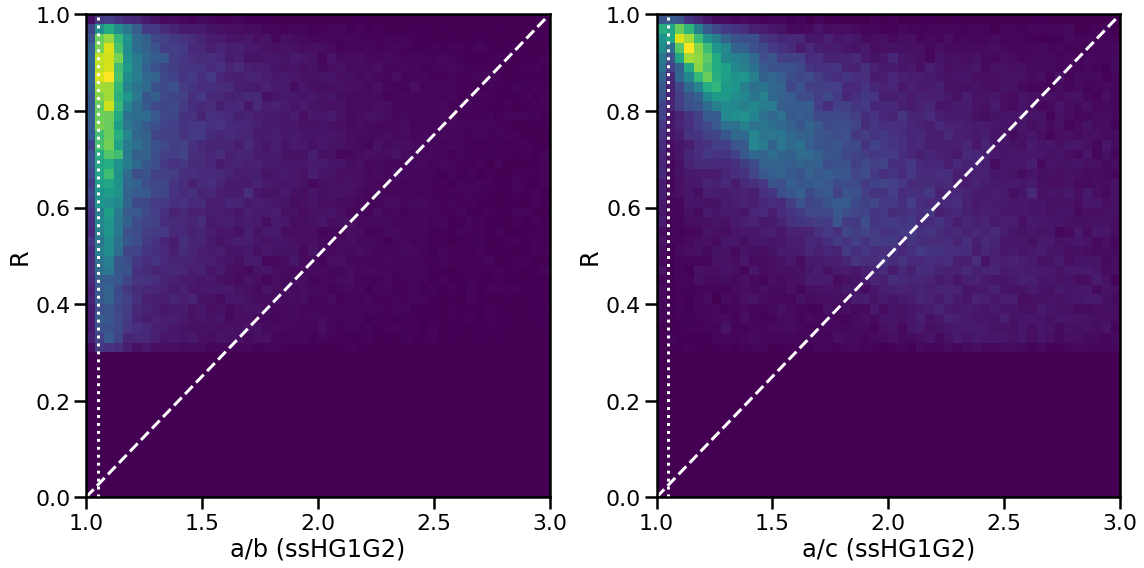

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

r_ab = [1, 3]
r_bc = [0, 1]
b_ab = 50
b_bc = 50
b_ac = 50

fields = ["a_b", "a_c"]
for index in range(2):
    axes[index].hist2d(
        ssoft[mask]["SSHG1G2_{}".format(fields[index])], 
        ssoft[mask]["SHG1G2_R"], 
        range=[r_ab, r_bc], 
        bins=[b_ab, b_bc]
    )

    axes[index].axvline(1.05, color='white', ls=":") # p0 in the fit
    

    axes[index].plot(r_ab, r_bc, color="white", ls='--')
    axes[index].set_xlabel("{} (ssHG1G2)".format(fields[index]).replace("_", "/"))
    axes[index].set_ylabel("R".format(fields[index]).replace("_", "/"))

# axes[1].legend(prop={'size': 15})
plt.tight_layout()

a/b is weird -- how R --> 1 can give a/b != 1. And there is a degeneracy. To my opinion, the fit does not converge (a/b --> 1).
Idea: make simulations of real sinus shifted with {small/big} error bars. Draw R from real distributions, and estimate a/b and a/c. How are the distributions for a/b?